In [1]:
!pip install seaborn matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.7 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 5.4 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.7 MB/s  0:00:01
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------------------------- -------- 7.6/9.8 MB 36.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 26.2 MB/s  0:00:00
Using 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart.csv')
sns.set_theme(style="whitegrid")

In [3]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


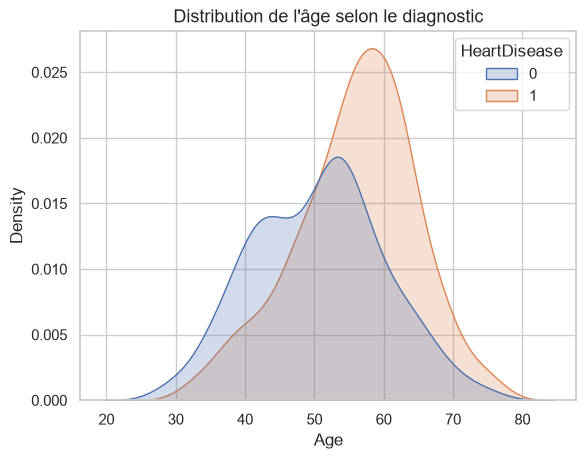

In [4]:
# Q1 : distribution de l'âge selon le diagnostic
sns.kdeplot(data=df, x="Age", hue="HeartDisease", fill=True)
#sns.figure(figsize=(8, 5))
plt.title("Distribution de l'âge selon le diagnostic", fontsize=13)
plt.xlabel("Age", fontsize=12)
plt.show()

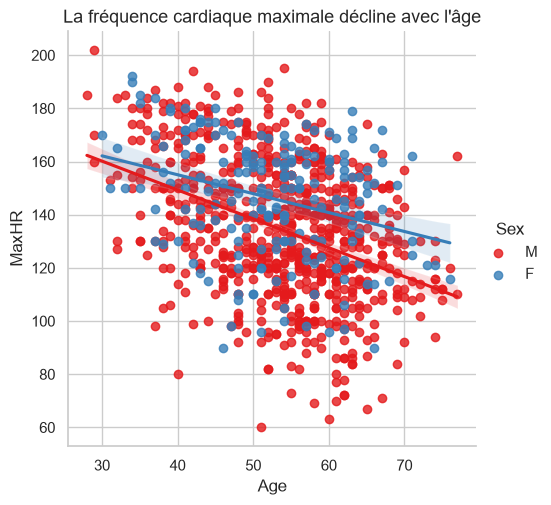

In [5]:
# Q2 : relation MaxHR / âge selon le sexe
#sns.lmplot(data=df, x="Age", y="MaxHR", hue="Sex")
sns.lmplot(data=df, x="Age", y="MaxHR", hue="Sex", palette="Set1")
plt.title("La fréquence cardiaque maximale décline avec l'âge", fontsize=13)
plt.show()

In [27]:
%pip install nbformat>=4.2

Note: you may need to restart the kernel to use updated packages.


In [6]:
import plotly.express as px

In [7]:
#  Q3 : répartition des types de douleur thoracique selon le diagnostic
fig = px.bar(df, x="ChestPainType", color="HeartDisease", barmode="group",
             title="Répartition des types de douleur thoracique selon le diagnostic",
             labels={"ChestPainType": "Type de douleur thoracique", "HeartDisease": "Diagnostic"})
fig.show()

In [8]:
# Q4 : composition des résultats d'ECG au repos
table = pd.crosstab(df['RestingECG'], df['HeartDisease'])
fig = px.imshow(table, text_auto=True, color_continuous_scale='Blues',
                title="Composition des resultats de l'ECG")
fig.show()

In [9]:
# Conversion de Q1 (kdeplot Seaborn -> version Plotly)
fig = px.histogram(df, x="Age", color="HeartDisease", marginal="box", nbins=30, 
                   title="Distribution de l'âge selon le diagnostic (Plotly version)")
fig.show()

In [10]:
# Q5 : profil du patient à risque (âge, fréquence cardiaque max,diagnostic)
fig = px.violin(df, y="MaxHR", x="HeartDisease", color="HeartDisease", box=True, points="all",
                title="Les patients à risque ont une fréquence cardiaque maximale plus faible",
                labels={"MaxHR": "Fréquence cardiaque maximale", "HeartDisease": "Diagnostic"})
fig.show()  